# Análise SBBD — k=10, apenas Ataque

Filtragem: `task == 'attack'` em todas as análises.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os

plt.rcParams['font.family'] = 'Times New Roman'

def mcc_from_counts(tp, fp, fn, tn):
    tp, fp, fn, tn = float(tp), float(fp), float(fn), float(tn)
    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / np.sqrt(den) if den > 0 else np.nan

def fbeta_from_counts(tp, fp, fn, beta=0.5):
    b2 = beta ** 2
    denom = (1 + b2) * tp + b2 * fn + fp
    return (1 + b2) * tp / denom if denom > 0 else np.nan

NOMES = {
    'v4 Page-Hinkley': 'Page-Hinkley',
    'v5 KSWIN':        'KSWIN',
    'v6 ADWIN':        'ADWIN',
    'v7 Baseline Fixo':'Baseline Fixo',
    'v8 Random Walk':  'Aleatório',
}
PALETTE = {
    'v4 Page-Hinkley': '#4C72B0',
    'v5 KSWIN':        '#55A868',
    'v6 ADWIN':        '#C44E52',
    'v7 Baseline Fixo':'#8172B2',
    'v8 Random Walk':  '#DD8452',
}
MARKERS = {
    'v4 Page-Hinkley': 'o',
    'v5 KSWIN':        's',
    'v6 ADWIN':        '^',
    'v7 Baseline Fixo':'D',
    'v8 Random Walk':  'X',
}
ORDER = ['v4 Page-Hinkley','v5 KSWIN','v6 ADWIN','v7 Baseline Fixo','v8 Random Walk']

TASK = 'attack'

FIG_DIR = '../figures/sbbd_k10_attack'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Dados

In [42]:
BASE = '../results'

def load_best(detector):
    df = pd.read_parquet(f'{BASE}/model_v5_k10/{detector}/results_best.parquet')
    return df[df['task'] == TASK].copy()

def load_best_side(detector):
    df = pd.read_parquet(f'{BASE}/model_v5_k10/{detector}/results_best_by_side.parquet')
    return df[df['task'] == TASK].copy()

v4 = load_best('02_model_page_hinkley')
v5 = load_best('02_model_kswin')
v6 = load_best('02_model_adwin')
v7 = load_best('02_model_baseline_fixed')
v8_raw = pd.read_parquet(f'{BASE}/model_v5_k10/02_model_baseline_random/results_best.parquet')
v8 = v8_raw[v8_raw['task'] == TASK].copy()

v4_side = load_best_side('02_model_page_hinkley')
v5_side = load_best_side('02_model_kswin')
v6_side = load_best_side('02_model_adwin')
v7_side = load_best_side('02_model_baseline_fixed')

for name in ['v5', 'v6', 'v5_side', 'v6_side']:
    df = locals()[name]
    if 'fast_grid' in df.columns:
        locals()[name] = df[df['fast_grid'] == False].copy()

for label, df in [('PH',v4),('KSWIN',v5),('ADWIN',v6),('Fixo',v7),('Aleat.',v8)]:
    print(f'{label}: {df.shape}')

PH: (120, 17)
KSWIN: (120, 19)
ADWIN: (120, 19)
Fixo: (20, 17)
Aleat.: (600, 18)


## 2. Helpers de agregação

In [43]:
def agg_configs(df, group_cols, label):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP_sum','sum'), FP=('FP_sum','sum'),
        FN=('FN_sum','sum'), TN=('TN_sum','sum')
    )
    g['mcc']       = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['f1']        = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    g['f05']       = g.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
    g['precision'] = g['TP'] / (g['TP'] + g['FP'])
    g['recall']    = g['TP'] / (g['TP'] + g['FN'])
    g['alarms']    = g['TP'] + g['FP']
    g['modelo']    = label
    return g

def aggregate_global(df):
    tp = df['TP_sum'].sum()
    fp = df['FP_sum'].sum()
    fn = df['FN_sum'].sum()
    tn = df['TN_sum'].sum() if 'TN_sum' in df.columns else None
    prec = tp / (tp+fp) if (tp+fp) > 0 else 0
    rec  = tp / (tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    b    = 0.5
    f05  = (1+b**2)*prec*rec/(b**2*prec+rec) if (b**2*prec+rec) > 0 else 0
    mcc  = None
    if tn is not None:
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        mcc = (tp*tn - fp*fn) / denom if denom > 0 else 0
    return {'TP': tp, 'FP': fp, 'FN': fn,
            'Precision': prec, 'Recall': rec, 'F1': f1, 'F0.5': f05, 'MCC': mcc}

configs = pd.concat([
    agg_configs(v4, ['window_ma'],        'v4 Page-Hinkley'),
    agg_configs(v5, ['window_ma'],        'v5 KSWIN'),
    agg_configs(v6, ['window_ma'],        'v6 ADWIN'),
    agg_configs(v7, ['interval_minutes'], 'v7 Baseline Fixo'),
], ignore_index=True)

# v8: results_best tem 3 linhas por (run_number, team) — uma para cada feature
# (passe, passe_certo, passe_errado). Diferente dos outros detectores, que têm um
# hiperparâmetro real (window_ma) cujo melhor valor é selecionado, o baseline
# aleatório dispara independentemente da feature. Por isso, somamos por
# (run_number, feature) e tiramos a média entre features antes de calcular as
# métricas — sem isso os alarmes seriam triplicados artificialmente.
v8_by_feat = v8.groupby(['run_number', 'feature'], as_index=False).agg(
    TP=('TP_sum','sum'), FP=('FP_sum','sum'), FN=('FN_sum','sum'), TN=('TN_sum','sum')
)
v8_runs = v8_by_feat.groupby('run_number', as_index=False).agg(
    TP=('TP','mean'), FP=('FP','mean'), FN=('FN','mean'), TN=('TN','mean')
)
v8_runs['mcc']       = v8_runs.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
v8_runs['f1']        = 2*v8_runs['TP'] / (2*v8_runs['TP'] + v8_runs['FP'] + v8_runs['FN'])
v8_runs['f05']       = v8_runs.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
v8_runs['precision'] = v8_runs['TP'] / (v8_runs['TP'] + v8_runs['FP'])
v8_runs['recall']    = v8_runs['TP'] / (v8_runs['TP'] + v8_runs['FN'])
v8_runs['alarms']    = v8_runs['TP'] + v8_runs['FP']

v8_stat = {m: {'mean': v8_runs[m].mean(), 'std': v8_runs[m].std()}
           for m in ['mcc','f1','f05','precision','recall','alarms']}

print('Aleatório (10 runs, attack):')
for m in ['mcc','f1','f05']:
    print(f'  {m}: {v8_stat[m]["mean"]:.4f} ± {v8_stat[m]["std"]:.4f}')
print(f'  alarmes: {v8_stat["alarms"]["mean"]:.0f}')

Aleatório (10 runs, attack):
  mcc: 0.0652 ± 0.0006
  f1: 0.0388 ± 0.0001
  f05: 0.0247 ± 0.0001
  alarmes: 36335


## 3. Tabela comparativa

In [44]:
rows = []
for label, grp in configs.groupby('modelo'):
    if label == 'v7 Baseline Fixo':
        grp = grp[grp['interval_minutes'] == 22]
    best = grp.sort_values('mcc', ascending=False).iloc[0]
    rows.append({
        'Modelo':    NOMES[label],
        'Precision': round(best.precision, 4),
        'Recall':    round(best.recall, 4),
        'F1':        round(best.f1, 4),
        'F0.5':      round(best.f05, 4),
        'MCC':       round(best.mcc, 4),
        'Alarmes':   int(best.alarms),
        '_modelo':   label,
    })
rows.append({
    'Modelo':    'Aleatório',
    'Precision': round(v8_stat['precision']['mean'], 4),
    'Recall':    round(v8_stat['recall']['mean'], 4),
    'F1':        round(v8_stat['f1']['mean'], 4),
    'F0.5':      round(v8_stat['f05']['mean'], 4),
    'MCC':       round(v8_stat['mcc']['mean'], 4),
    'Alarmes':   int(v8_stat['alarms']['mean']),
    '_modelo':   'v8 Random Walk',
})

comp = pd.DataFrame(rows).set_index('Modelo')

display(
    comp.drop(columns=['_modelo'])
    .sort_values('MCC', ascending=False)
    .style
    .format('{:.4f}', subset=['Precision','Recall','F1','F0.5','MCC'])
    .highlight_max(subset=['F1','F0.5','MCC'], color='#d4edda')
    .highlight_min(subset=['F1','F0.5','MCC'], color='#f8d7da')
)
print(f"\nAleatório IC (±1σ): F1={v8_stat['f1']['mean']:.4f}±{v8_stat['f1']['std']:.4f} | MCC={v8_stat['mcc']['mean']:.4f}±{v8_stat['mcc']['std']:.4f}")

,Precision,Recall,F1,F0.5,MCC,Alarmes
Modelo,,,,,,
Page-Hinkley,0.0709,0.3639,0.1187,0.0846,0.1372,13390
KSWIN,0.0860,0.1939,0.1191,0.0967,0.1123,5616
Aleatório,0.0199,0.7884,0.0388,0.0247,0.0652,36334
Baseline Fixo,0.0325,0.1080,0.0500,0.0378,0.0373,3040
ADWIN,0.1683,0.0083,0.0158,0.0347,0.0348,123



Aleatório IC (±1σ): F1=0.0388±0.0001 | MCC=0.0652±0.0006


## 4. Barras MCC + F1 por modelo

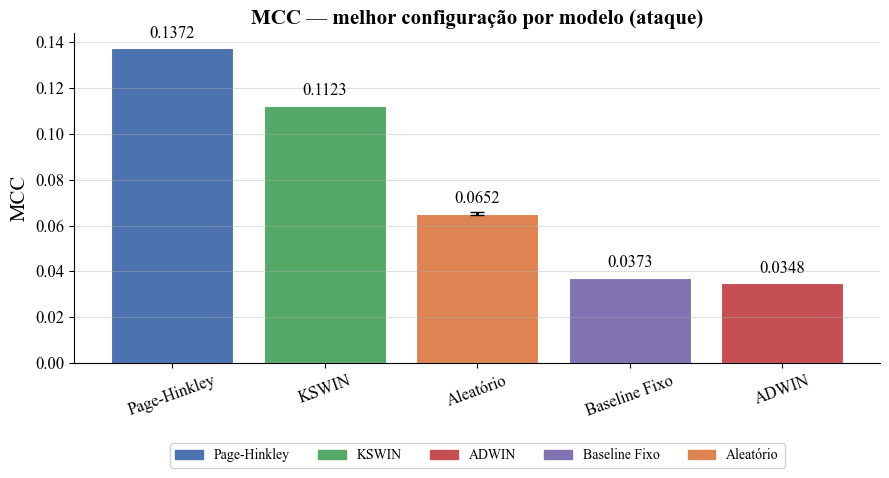

In [45]:
comp_sorted = comp.sort_values('MCC', ascending=False).reset_index()
colors = [PALETTE[m] for m in comp_sorted['_modelo']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comp_sorted['Modelo'], comp_sorted['MCC'],
              color=colors, edgecolor='white', linewidth=0.8)

v8_idx = comp_sorted[comp_sorted['_modelo']=='v8 Random Walk'].index
if len(v8_idx):
    ax.errorbar(v8_idx[0], comp_sorted.loc[v8_idx[0], 'MCC'],
                yerr=v8_stat['mcc']['std'],
                fmt='none', color='black', capsize=5, linewidth=2)

for bar, val in zip(bars, comp_sorted['MCC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)

leg_handles = [
    mpatches.Patch(color=PALETTE[k], label=NOMES[k])
    for k in ORDER
]
ax.legend(handles=leg_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=5,
          fontsize=10, framealpha=0.9, edgecolor='#ccc')

ax.set_ylabel('MCC', fontsize=15)
ax.set_title('MCC — melhor configuração por modelo (ataque)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=20, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_comparacao_mcc.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

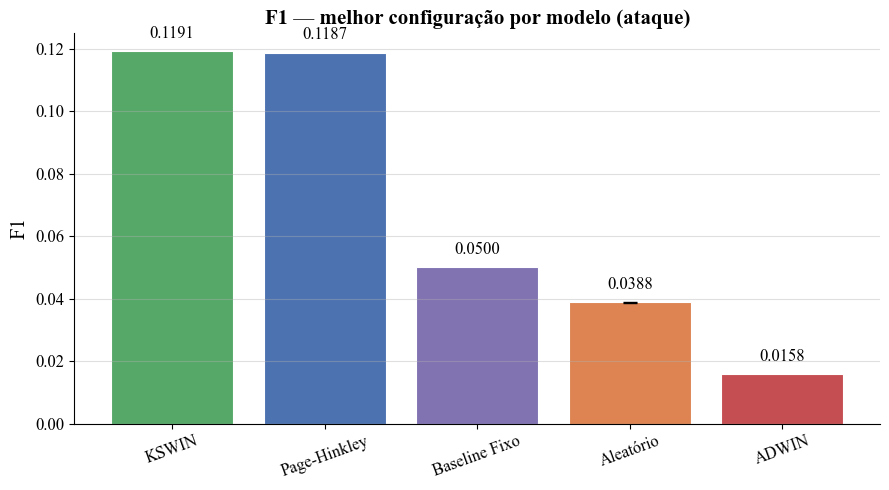

In [46]:
comp_f1 = comp.sort_values('F1', ascending=False).reset_index()
colors_f1 = [PALETTE[m] for m in comp_f1['_modelo']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comp_f1['Modelo'], comp_f1['F1'],
              color=colors_f1, edgecolor='white', linewidth=0.8)

v8_idx = comp_f1[comp_f1['_modelo']=='v8 Random Walk'].index
if len(v8_idx):
    ax.errorbar(v8_idx[0], comp_f1.loc[v8_idx[0], 'F1'],
                yerr=v8_stat['f1']['std'],
                fmt='none', color='black', capsize=5, linewidth=2)

for bar, val in zip(bars, comp_f1['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)

ax.set_ylabel('F1', fontsize=15)
ax.set_title('F1 — melhor configuração por modelo (ataque)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=20, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_comparacao_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 5. MCC × Volume de Alarmes

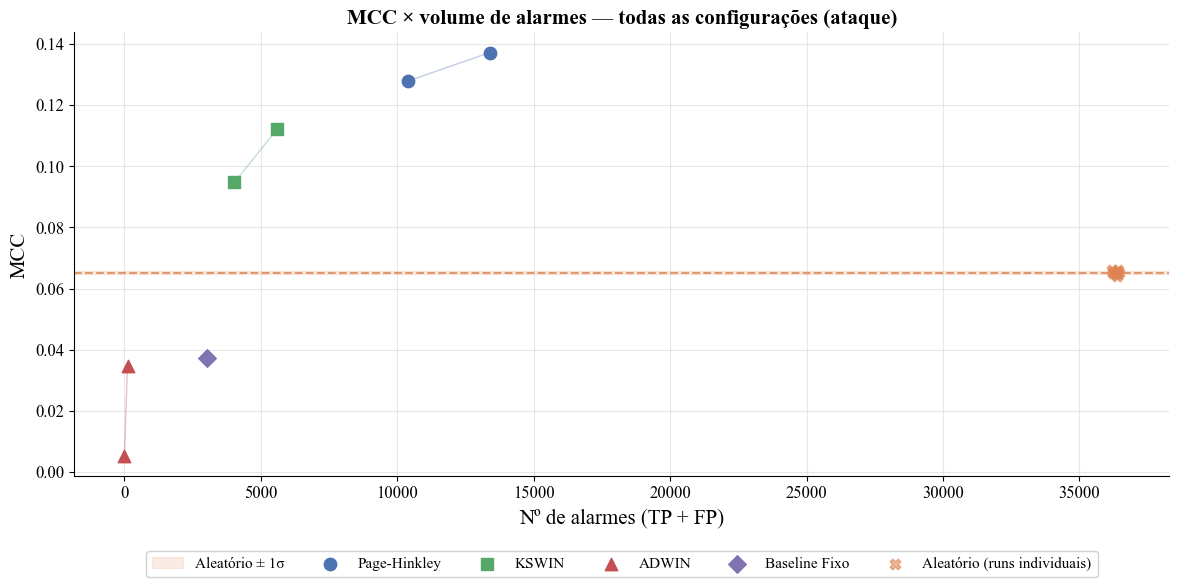

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

m_mean, m_std = v8_stat['mcc']['mean'], v8_stat['mcc']['std']
ax.axhspan(m_mean - m_std, m_mean + m_std,
           alpha=0.15, color=PALETTE['v8 Random Walk'], label='Aleatório ± 1σ')
ax.axhline(m_mean, linestyle='--', color=PALETTE['v8 Random Walk'], linewidth=1.5, alpha=0.8)

for modelo, grp in configs.groupby('modelo'):
    grp_s = grp.sort_values('alarms')
    ax.scatter(grp_s['alarms'], grp_s['mcc'],
               label=NOMES[modelo], color=PALETTE[modelo],
               marker=MARKERS[modelo], s=80, zorder=3)
    ax.plot(grp_s['alarms'], grp_s['mcc'], color=PALETTE[modelo], alpha=0.35, linewidth=1)

ax.scatter(v8_runs['alarms'], v8_runs['mcc'],
           color=PALETTE['v8 Random Walk'], marker='X', s=60, zorder=2, alpha=0.6,
           label='Aleatório (runs individuais)')

ax.set_xlabel('Nº de alarmes (TP + FP)', fontsize=15)
ax.set_ylabel('MCC', fontsize=15)
ax.set_title('MCC × volume de alarmes — todas as configurações (ataque)', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=6, fontsize=11, framealpha=0.9, edgecolor='#ccc')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mcc_vs_alarmes.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 6. MCC por faixa de volume

/var/folders/2k/92jn_r151_x51sr3n1nqb7fc0000gn/T/ipykernel_3249/697171567.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  configs.groupby(['faixa','modelo'], as_index=False)['mcc'].max()


,Page-Hinkley,KSWIN,ADWIN,Baseline Fixo
faixa,,,,
"< 1,5k",—,—,0.0348,—
"1,5k–3,5k",—,—,—,0.0373
"3,5k–6,5k",—,0.1123,—,—
"6,5k–11k",0.1279,—,—,—
11k–30k,0.1372,—,—,—


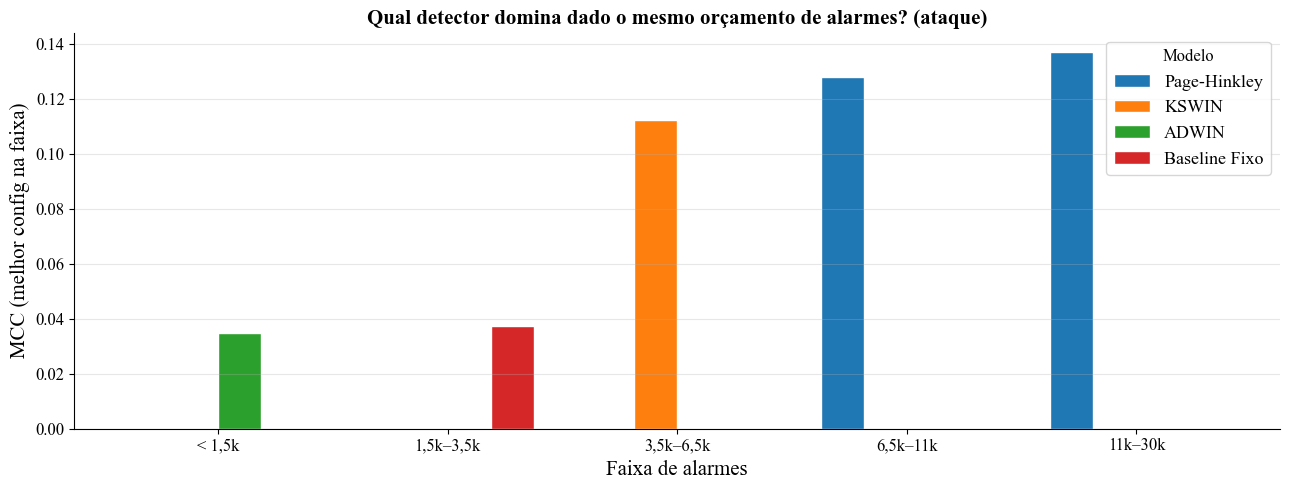

In [48]:
bins        = [0, 1500, 3500, 6500, 11000, 30000]
labels_bins = ['< 1,5k', '1,5k–3,5k', '3,5k–6,5k', '6,5k–11k', '11k–30k']

configs['faixa'] = pd.cut(configs['alarms'], bins=bins, labels=labels_bins)

pivot_faixa = (
    configs.groupby(['faixa','modelo'], as_index=False)['mcc'].max()
    .pivot(index='faixa', columns='modelo', values='mcc')
    .reindex(labels_bins)
)
pivot_faixa.columns = [NOMES[c] for c in pivot_faixa.columns]

display(
    pivot_faixa.style
    .highlight_max(axis=1, props='font-weight:bold; background-color:#d4edda')
    .format('{:.4f}', na_rep='—')
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_faixa.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_xlabel('Faixa de alarmes', fontsize=15)
ax.set_ylabel('MCC (melhor config na faixa)', fontsize=15)
ax.set_title('Qual detector domina dado o mesmo orçamento de alarmes? (ataque)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13, title='Modelo', title_fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mcc_por_faixa.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Mandante vs. Visitante

Side,Mandante,Visitante
Modelo,,
Page-Hinkley,0.1603,0.1394
KSWIN,0.1599,0.1396
Baseline Fixo,0.0580,0.0413
ADWIN,0.0111,0.0223


Side,Mandante,Visitante
Modelo,,
Page-Hinkley,0.3652,0.3274
KSWIN,0.2222,0.1879
Baseline Fixo,0.1123,0.1021
ADWIN,0.0057,0.0115


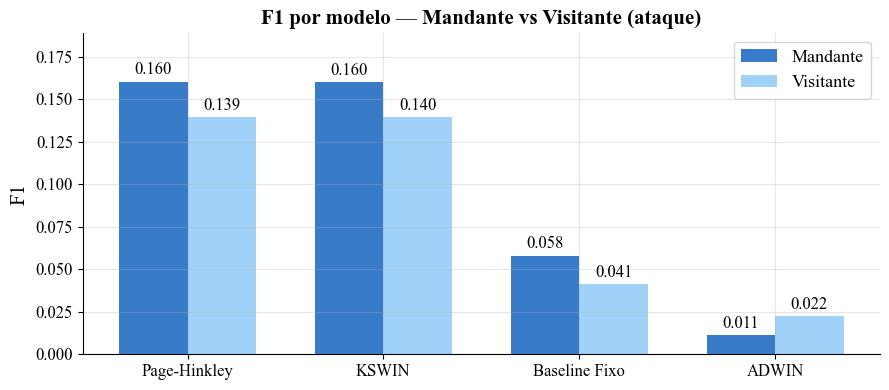

In [49]:
def summary_by_side(df, name):
    rows = []
    for side in ['casa', 'fora']:
        sub  = df[df['side'] == side]
        best = sub.loc[sub.groupby('team')['f1'].idxmax()]
        m    = aggregate_global(best)
        m['Modelo'] = name
        m['Side']   = 'Mandante' if side == 'casa' else 'Visitante'
        rows.append(m)
    return rows

side_rows = []
for name, df in [('Page-Hinkley', v4_side), ('KSWIN', v5_side),
                 ('ADWIN', v6_side), ('Baseline Fixo', v7_side)]:
    side_rows.extend(summary_by_side(df, name))

df_side = pd.DataFrame(side_rows)

pivot_f1 = df_side.pivot(index='Modelo', columns='Side', values='F1')
pivot_rc = df_side.pivot(index='Modelo', columns='Side', values='Recall')
order = pivot_f1.mean(axis=1).sort_values(ascending=False).index
pivot_f1 = pivot_f1.loc[order]
pivot_rc = pivot_rc.loc[order]

display(pivot_f1.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#d4edda')
    .set_caption('F1 — Mandante vs Visitante (ataque)'))

display(pivot_rc.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#cce5ff')
    .set_caption('Recall — Mandante vs Visitante (ataque)'))

modelos = pivot_f1.index.tolist()
x = np.arange(len(modelos))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, pivot_f1['Mandante'], w, label='Mandante', color='#1565C0', alpha=0.85)
ax.bar(x + w/2, pivot_f1['Visitante'], w, label='Visitante',  color='#90CAF9', alpha=0.85)

for i, (c, f) in enumerate(zip(pivot_f1['Mandante'], pivot_f1['Visitante'])):
    ax.text(i - w/2, c + 0.002, f'{c:.3f}', ha='center', va='bottom', fontsize=12)
    ax.text(i + w/2, f + 0.002, f'{f:.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=12)
ax.set_ylabel('F1', fontsize=15)
ax.set_title('F1 por modelo — Mandante vs Visitante (ataque)', fontsize=15, fontweight='bold')
ax.legend(fontsize=13)
ax.set_ylim(0, max(pivot_f1.values.max(), 0.01) * 1.18)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_casa_fora_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 8. F1 vs F0.5

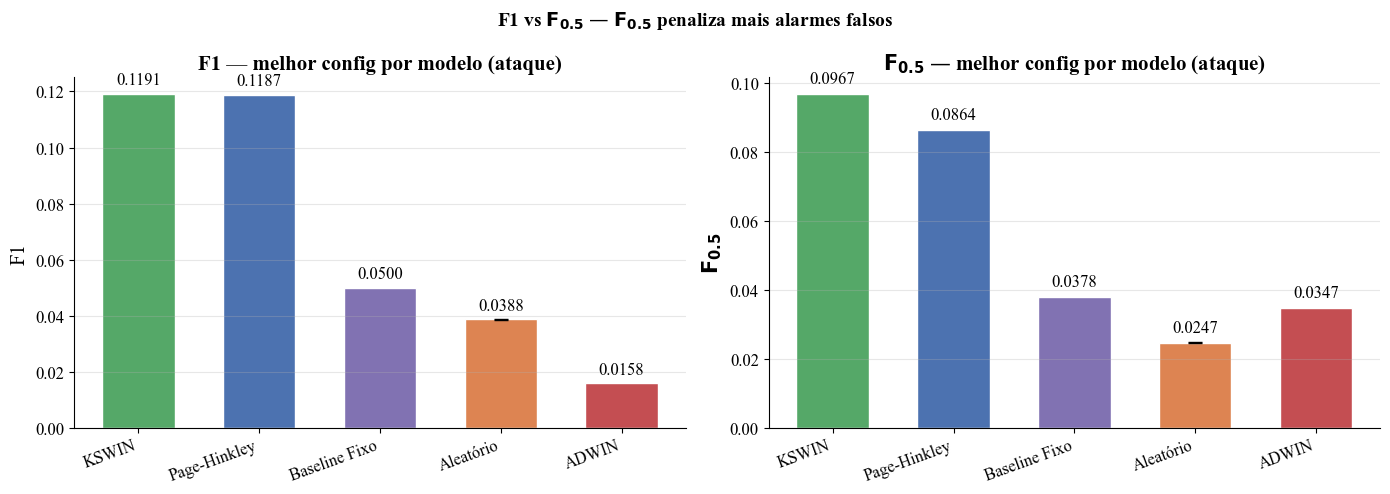

In [50]:
fbeta_rows = []
for label, grp in configs.groupby('modelo'):
    if label == 'v7 Baseline Fixo':
        grp = grp[grp['interval_minutes'] == 22]
    best_f1  = grp.sort_values('f1',  ascending=False).iloc[0]
    best_f05 = grp.sort_values('f05', ascending=False).iloc[0]
    fbeta_rows.append({'Modelo': NOMES[label], '_modelo': label,
                       'F1': best_f1.f1, 'F0.5': best_f05.f05})
fbeta_rows.append({'Modelo': 'Aleatório', '_modelo': 'v8 Random Walk',
                   'F1': v8_stat['f1']['mean'], 'F0.5': v8_stat['f05']['mean']})

fbeta_comp = pd.DataFrame(fbeta_rows).set_index('Modelo').sort_values('F1', ascending=False)
colors_fb  = [PALETTE[m] for m in fbeta_comp['_modelo']]
x_fb = np.arange(len(fbeta_comp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel in zip(axes, ['F1','F0.5'], ['F1','$\\mathbf{F_{0.5}}$']):
    bars = ax.bar(x_fb, fbeta_comp[metric], color=colors_fb, edgecolor='white', width=0.6)
    std_key = 'f1' if metric == 'F1' else 'f05'
    v8_idx = list(fbeta_comp.index).index('Aleatório')
    ax.errorbar(v8_idx, fbeta_comp.iloc[v8_idx][metric],
                yerr=v8_stat[std_key]['std'],
                fmt='none', color='black', capsize=5, linewidth=2)
    for bar, val in zip(bars, fbeta_comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=12)
    ax.set_xticks(x_fb)
    ax.set_xticklabels(fbeta_comp.index, rotation=20, ha='right', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(f'{ylabel} — melhor config por modelo (ataque)', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('F1 vs $\\mathbf{F_{0.5}}$ — $\\mathbf{F_{0.5}}$ penaliza mais alarmes falsos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_f1_vs_f05.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Melhores hiperparâmetros por modelo

In [51]:
hp_rows = []

for label, grp_orig, gc in [
    ('v4 Page-Hinkley', v4, ['window_ma']),
    ('v5 KSWIN',        v5, ['window_ma']),
    ('v6 ADWIN',        v6, ['window_ma']),
]:
    g = agg_configs(grp_orig, gc, label)
    best = g.sort_values('mcc', ascending=False).iloc[0]
    best_feat = agg_configs(grp_orig, gc + ['feature'], label).sort_values('mcc', ascending=False).iloc[0]
    hp_rows.append({
        'Modelo':   NOMES[label],
        'W':        int(best.window_ma),
        'Intervalo':'—',
        'Feature':  best_feat.feature,
        'MCC':      round(best.mcc, 4),
        'F1':       round(best.f1, 4),
        'Alarmes':  int(best.alarms),
    })

g7 = agg_configs(v7, ['interval_minutes'], 'v7 Baseline Fixo')
best7 = g7.sort_values('mcc', ascending=False).iloc[0]
hp_rows.append({
    'Modelo':    'Baseline Fixo',
    'W':         '—',
    'Intervalo': int(best7.interval_minutes),
    'Feature':   '—',
    'MCC':       round(best7.mcc, 4),
    'F1':        round(best7.f1, 4),
    'Alarmes':   int(best7.alarms),
})

hp_rows.append({
    'Modelo':    'Aleatório',
    'W': '—', 'Intervalo': '—', 'Feature': '—',
    'MCC':     round(v8_stat['mcc']['mean'], 4),
    'F1':      round(v8_stat['f1']['mean'], 4),
    'Alarmes': int(v8_stat['alarms']['mean']),
})

hp_df = pd.DataFrame(hp_rows).set_index('Modelo')
display(hp_df)

,W,Intervalo,Feature,MCC,F1,Alarmes
Modelo,,,,,,
Page-Hinkley,3,—,passe,0.1372,0.1187,13390
KSWIN,5,—,passe,0.1123,0.1191,5616
ADWIN,5,—,passe_certo,0.0348,0.0158,123
Baseline Fixo,—,22,—,0.0373,0.0500,3040
Aleatório,—,—,—,0.0652,0.0388,36334


## 10. Curva Precisão × Recall

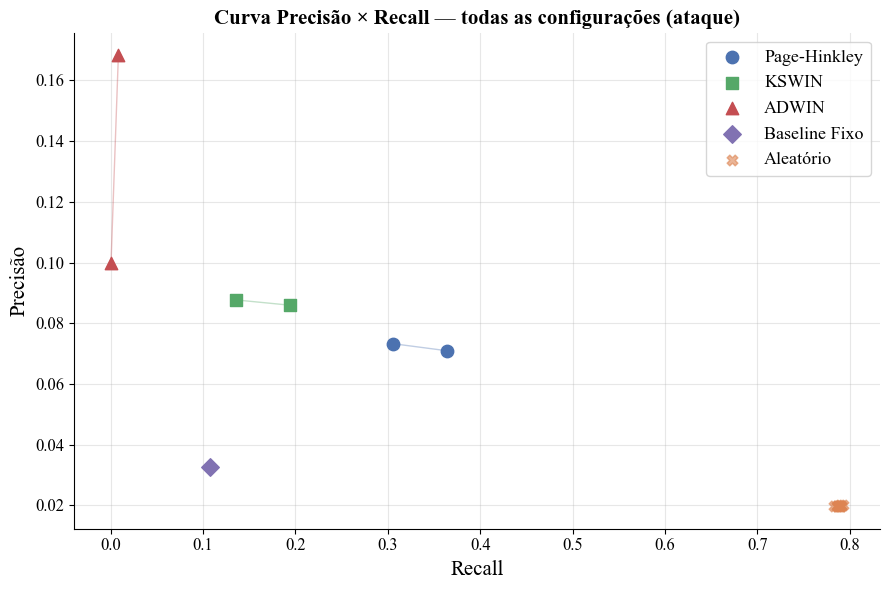

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))

for modelo in ORDER:
    if modelo == 'v8 Random Walk':
        continue
    grp = configs[configs['modelo'] == modelo].sort_values('recall')
    ax.scatter(grp['recall'], grp['precision'],
               label=NOMES[modelo], color=PALETTE[modelo],
               marker=MARKERS[modelo], s=80, zorder=3)
    ax.plot(grp['recall'], grp['precision'],
            color=PALETTE[modelo], alpha=0.35, linewidth=1)

ax.scatter(v8_runs['recall'], v8_runs['precision'],
           label='Aleatório', color=PALETTE['v8 Random Walk'],
           marker=MARKERS['v8 Random Walk'], s=60, alpha=0.6, zorder=2)

ax.set_xlabel('Recall', fontsize=15)
ax.set_ylabel('Precisão', fontsize=15)
ax.set_title('Curva Precisão × Recall — todas as configurações (ataque)', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(fontsize=13, loc='upper right')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_pr_curve.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 11. Análise In-Sample — Protocolo B (teto de desempenho)

Para cada time seleciona-se independentemente a configuração que maximiza o MCC naquele subconjunto.
N_SERIES = 380 partidas × 2 times × 1 tarefa (ataque) = 760 séries.

In [53]:
N_SERIES = 760  # 380 × 2 times × 1 tarefa

def proto_b(df):
    d = df.copy()
    d['mcc_row'] = d.apply(lambda r: mcc_from_counts(r.TP_sum, r.FP_sum, r.FN_sum, r.TN_sum), axis=1).fillna(0)
    best_idx = d.groupby('team')['mcc_row'].idxmax()
    return d.loc[best_idx].copy()

def global_b(df, name):
    tp = df['TP_sum'].sum(); fp = df['FP_sum'].sum()
    fn = df['FN_sum'].sum(); tn = df['TN_sum'].sum()
    mcc  = mcc_from_counts(tp, fp, fn, tn)
    f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    return {
        'Modelo': name, 'MCC': round(mcc, 4), 'F1': round(f1, 4),
        'Recall': round(rec, 4), 'Precisão': round(prec, 4),
        'Alarmes': int(tp + fp),
        'Al./partida': round((tp + fp) / N_SERIES, 1),
    }

b_ph = proto_b(v4)
b_ks = proto_b(v5)
b_ad = proto_b(v6)
b_fi = proto_b(v7)

v8_b = v8.copy()
v8_b['mcc_row'] = v8_b.apply(
    lambda r: mcc_from_counts(r.TP_sum, r.FP_sum, r.FN_sum, r.TN_sum), axis=1
).fillna(0)
b_rd = v8_b.loc[v8_b.groupby(['team', 'run_number'])['mcc_row'].idxmax()].copy()

rd_runs = b_rd.groupby('run_number', as_index=False).agg(
    TP=('TP_sum','sum'), FP=('FP_sum','sum'), FN=('FN_sum','sum'), TN=('TN_sum','sum')
)
rd_runs['mcc']    = rd_runs.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
rd_runs['f1']     = 2*rd_runs['TP'] / (2*rd_runs['TP'] + rd_runs['FP'] + rd_runs['FN'])
rd_runs['rec']    = rd_runs['TP'] / (rd_runs['TP'] + rd_runs['FN'])
rd_runs['prec']   = rd_runs['TP'] / (rd_runs['TP'] + rd_runs['FP'])
rd_runs['alarms'] = rd_runs['TP'] + rd_runs['FP']

rows_b = [
    global_b(b_ph, 'Page-Hinkley'),
    global_b(b_ks, 'KSWIN'),
    global_b(b_ad, 'ADWIN'),
    global_b(b_fi, 'Baseline Fixo'),
    {
        'Modelo':      'Aleatório',
        'MCC':         round(rd_runs['mcc'].mean(), 4),
        'F1':          round(rd_runs['f1'].mean(),  4),
        'Recall':      round(rd_runs['rec'].mean(), 4),
        'Precisão':    round(rd_runs['prec'].mean(), 4),
        'Alarmes':     int(rd_runs['alarms'].mean()),
        'Al./partida': round(rd_runs['alarms'].mean() / N_SERIES, 1),
    }
]

df_proto_b = pd.DataFrame(rows_b).set_index('Modelo')
display(
    df_proto_b.sort_values('MCC', ascending=False)
    .style
    .format({'MCC': '{:.4f}', 'F1': '{:.4f}', 'Recall': '{:.4f}',
             'Precisão': '{:.4f}', 'Alarmes': '{:,.0f}', 'Al./partida': '{:.1f}'})
    .highlight_max(subset=['MCC', 'F1', 'Recall'], color='#d4edda')
    .highlight_min(subset=['MCC', 'F1', 'Recall'], color='#f8d7da')
    .set_caption('Protocolo B — melhor config por time, ataque, K=10 | Al./partida = total / 760 séries')
)
print(f"Aleatório: MCC={rd_runs['mcc'].mean():.4f} ± {rd_runs['mcc'].std():.4f}")
print(f"Aleatório: Al./partida={rd_runs['alarms'].mean()/N_SERIES:.1f} ± {rd_runs['alarms'].std()/N_SERIES:.1f}")

,MCC,F1,Recall,Precisão,Alarmes,Al./partida
Modelo,,,,,,
Page-Hinkley,0.1517,0.1242,0.4256,0.0727,"5,017",6.6
KSWIN,0.1196,0.1266,0.1983,0.0930,"1,792",2.4
Aleatório,0.0691,0.0397,0.8043,0.0203,"36,219",47.7
Baseline Fixo,0.0373,0.0500,0.1080,0.0325,"3,040",4.0
ADWIN,0.0344,0.0155,0.0081,0.1683,41,0.1


Aleatório: MCC=0.0691 ± 0.0006
Aleatório: Al./partida=47.7 ± 0.1


## 12. Robustez da seleção de hiperparâmetros — divisão temporal

Primeiros 190 jogos → seleção; últimos 190 jogos → avaliação out-of-sample. Filtrado para ataque.

Treino: 190 jogos  (até 2016-01-16)
Teste:  190 jogos  (de  2016-01-16 em diante)
Page-Hinkley     treino=0.1330  teste=0.1320  Δ=-0.0010  (in-sample=0.1326)
KSWIN            treino=0.0921  teste=0.0875  Δ=-0.0045  (in-sample=0.0896)
ADWIN            treino=0.0103  teste=0.0303  Δ=+0.0200  (in-sample=0.0218)


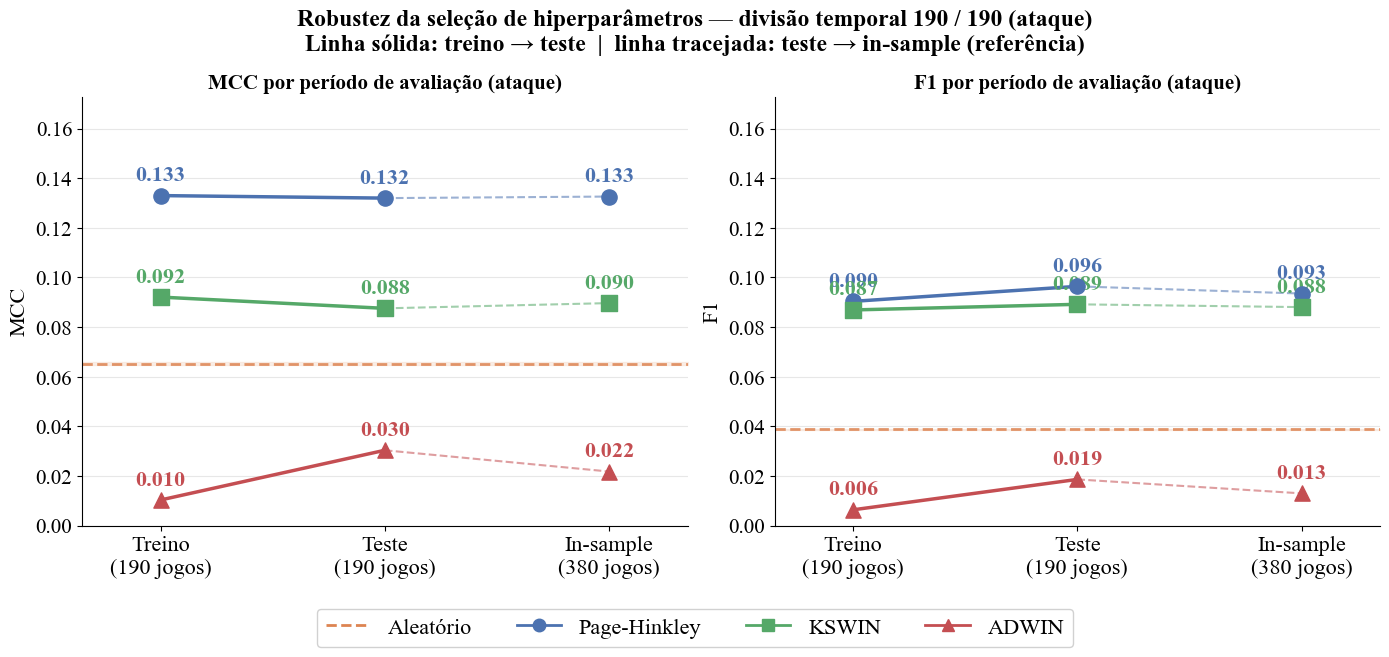

In [54]:
import json

with open('../data/open-data/data/matches/11/27.json') as f:
    _matches_raw = json.load(f)

df_match_dates = pd.DataFrame([{
    'match_id':   m['match_id'],
    'match_date': pd.to_datetime(m['match_date']),
} for m in _matches_raw]).sort_values('match_date').reset_index(drop=True)

_half = len(df_match_dates) // 2
train_ids = set(df_match_dates.iloc[:_half]['match_id'])
test_ids  = set(df_match_dates.iloc[_half:]['match_id'])

print(f"Treino: {len(train_ids)} jogos  (até {df_match_dates.iloc[_half-1]['match_date'].date()})")
print(f"Teste:  {len(test_ids)} jogos  (de  {df_match_dates.iloc[_half]['match_date'].date()} em diante)")

GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

def _agg_raw(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum')
    )
    g['mcc'] = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['f1']  = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    g['f05'] = g.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
    g['precision'] = g['TP'] / (g['TP'] + g['FP'])
    g['recall']    = g['TP'] / (g['TP'] + g['FN'])
    return g

DETECTORS = [
    ('v4 Page-Hinkley', '../results/model_v5_k10/02_model_page_hinkley/results_raw.parquet'),
    ('v5 KSWIN',        '../results/model_v5_k10/02_model_kswin/results_raw.parquet'),
    ('v6 ADWIN',        '../results/model_v5_k10/02_model_adwin/results_raw.parquet'),
]

rows_tv = []
summary = {}

for label, path in DETECTORS:
    raw = pd.read_parquet(path)
    raw = raw[raw['task'] == TASK].copy()

    train_agg = _agg_raw(raw[raw['match_id'].isin(train_ids)], GC)
    best      = train_agg.sort_values('mcc', ascending=False).iloc[0]

    mask = (
        (raw['window_ma']        == best.window_ma) &
        (raw['cooldown_minutes'] == best.cooldown_minutes) &
        (raw['feature']          == best.feature) &
        (raw['params']           == best.params)
    )
    test_rows = raw[mask & raw['match_id'].isin(test_ids)]
    tp_t = test_rows['TP'].sum(); fp_t = test_rows['FP'].sum()
    fn_t = test_rows['FN'].sum(); tn_t = test_rows['TN'].sum()
    mcc_t = mcc_from_counts(tp_t, fp_t, fn_t, tn_t)
    f1_t  = 2*tp_t / (2*tp_t + fp_t + fn_t) if (2*tp_t + fp_t + fn_t) > 0 else 0.0
    f05_t = fbeta_from_counts(tp_t, fp_t, fn_t, 0.5)

    all_agg  = _agg_raw(raw, GC)
    best_all = all_agg.sort_values('mcc', ascending=False).iloc[0]

    cfg_str = f"W={int(best.window_ma)}, C={int(best.cooldown_minutes)}, {best.feature}"
    nome = NOMES[label]

    rows_tv += [
        {'Modelo': nome, 'Conjunto': 'Treino (190)',    'Config': cfg_str,
         'MCC': round(best.mcc, 4), 'F1': round(best.f1, 4), 'F0.5': round(best.f05, 4)},
        {'Modelo': nome, 'Conjunto': 'Teste (190)',     'Config': cfg_str,
         'MCC': round(mcc_t, 4),    'F1': round(f1_t,   4), 'F0.5': round(f05_t,   4)},
        {'Modelo': nome, 'Conjunto': 'In-sample (380)', 'Config': f"W={int(best_all.window_ma)}, C={int(best_all.cooldown_minutes)}, {best_all.feature}",
         'MCC': round(best_all.mcc, 4), 'F1': round(best_all.f1, 4), 'F0.5': round(best_all.f05, 4)},
    ]
    summary[label] = {
        'treino':   {'mcc': best.mcc,     'f1': best.f1},
        'teste':    {'mcc': mcc_t,        'f1': f1_t},
        'insample': {'mcc': best_all.mcc, 'f1': best_all.f1},
    }
    print(f"{nome:15s}  treino={best.mcc:.4f}  teste={mcc_t:.4f}  "
          f"Δ={mcc_t-best.mcc:+.4f}  (in-sample={best_all.mcc:.4f})")

tv_df = pd.DataFrame(rows_tv).set_index(['Modelo', 'Conjunto'])
display(
    tv_df.style
    .format('{:.4f}', subset=['MCC', 'F1', 'F0.5'])
    .set_caption('Robustez — divisão temporal 190/190 (ataque, K=10)')
)

detectors_order = ['v4 Page-Hinkley', 'v5 KSWIN', 'v6 ADWIN']
x_pts    = [0, 1, 2]
x_labels = ['Treino\n(190 jogos)', 'Teste\n(190 jogos)', 'In-sample\n(380 jogos)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in zip(axes, ['mcc', 'f1'], ['MCC', 'F1']):
    rw_m = v8_stat[metric]['mean']
    rw_s = v8_stat[metric]['std']
    ax.fill_between([-0.35, 2.35], rw_m - rw_s, rw_m + rw_s,
                    color=PALETTE['v8 Random Walk'], alpha=0.12, zorder=0)
    ax.axhline(rw_m, linestyle='--', color=PALETTE['v8 Random Walk'],
               linewidth=2, alpha=0.85, zorder=1)

    for label in detectors_order:
        vals = [
            summary[label]['treino'][metric],
            summary[label]['teste'][metric],
            summary[label]['insample'][metric],
        ]
        color  = PALETTE[label]
        marker = MARKERS[label]

        ax.plot(x_pts[:2], vals[:2], '-', color=color, linewidth=2.5, zorder=2)
        ax.plot(x_pts[1:], vals[1:], '--', color=color, linewidth=1.5, alpha=0.55, zorder=2)
        ax.scatter(x_pts, vals, color=color, marker=marker, s=120, zorder=4)

        for xi, val in zip(x_pts, vals):
            ax.text(xi, val + 0.004, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=16, color=color, fontweight='bold')

    ax.set_xticks(x_pts)
    ax.set_xticklabels(x_labels, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(f'{ylabel} por período de avaliação (ataque)', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.set_xlim(-0.35, 2.35)
    ymax = max(summary[lab][k][metric] for lab in detectors_order for k in summary[lab])
    ax.set_ylim(0, ymax * 1.3)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

shared_ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, shared_ymax)

leg_handles = [
    mlines.Line2D([], [], color=PALETTE['v8 Random Walk'], linestyle='--',
                  linewidth=2, label='Aleatório'),
]
for lbl in detectors_order:
    leg_handles.append(
        mlines.Line2D([], [], color=PALETTE[lbl], marker=MARKERS[lbl],
                      markersize=9, linewidth=2, label=NOMES[lbl])
    )
fig.legend(handles=leg_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.0), ncol=4,
           fontsize=16, framealpha=0.9, edgecolor='#ccc')

plt.suptitle(
    'Robustez da seleção de hiperparâmetros — divisão temporal 190 / 190 (ataque)\n'
    'Linha sólida: treino → teste  |  linha tracejada: teste → in-sample (referência)',
    fontsize=17, fontweight='bold'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig(f'{FIG_DIR}/fig_robustez_train_test.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 13. Recall absoluto — Page-Hinkley (ataque)

In [55]:
raw_ph = pd.read_parquet('../results/model_v5_k10/02_model_page_hinkley/results_raw.parquet')
raw_ph = raw_ph[raw_ph['task'] == TASK].copy()

GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

def _agg_raw_recall(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum')
    )
    g['mcc']    = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['recall'] = g['TP'] / (g['TP'] + g['FN'])
    g['f1']     = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    return g

best_ph = _agg_raw_recall(raw_ph, GC).sort_values('mcc', ascending=False).iloc[0]

TOTAL_GOLS = int(best_ph.TP + best_ph.FN)
recall_ph     = best_ph.recall
gols_cobertos = recall_ph * TOTAL_GOLS

print("=== Page-Hinkley — melhor configuração (in-sample, ataque) ===")
print(f"  Config:        W={int(best_ph.window_ma)}, C={int(best_ph.cooldown_minutes)}, feature={best_ph.feature}")
print(f"  TP:            {best_ph.TP:.0f}")
print(f"  FN:            {best_ph.FN:.0f}")
print(f"  Total eventos: {TOTAL_GOLS}")
print(f"  Recall:        {recall_ph:.4f}  ({recall_ph*100:.1f}%)")
print(f"  Gols cobertos: ~{gols_cobertos:.0f} de {TOTAL_GOLS}  ({recall_ph*100:.1f}%)")

=== Page-Hinkley — melhor configuração (in-sample, ataque) ===
  Config:        W=3, C=5, feature=passe
  TP:            453
  FN:            417
  Total eventos: 870
  Recall:        0.5210  (52.1%)
  Gols cobertos: ~453 de 870  (52.1%)


## 14. Teste de permutação — Page-Hinkley vs. KSWIN (ataque)

Partidas em comum: 380
MCC Page-Hinkley: 0.1326  (W=3, C=5, passe)
MCC KSWIN:        0.0896  (W=5, C=3, passe)
Diferença observada: 0.0429

=== Resultado (1000 permutações) ===
p-valor (bicaudal): 0.0000
→ Diferença estatisticamente significativa (p < 0,05)


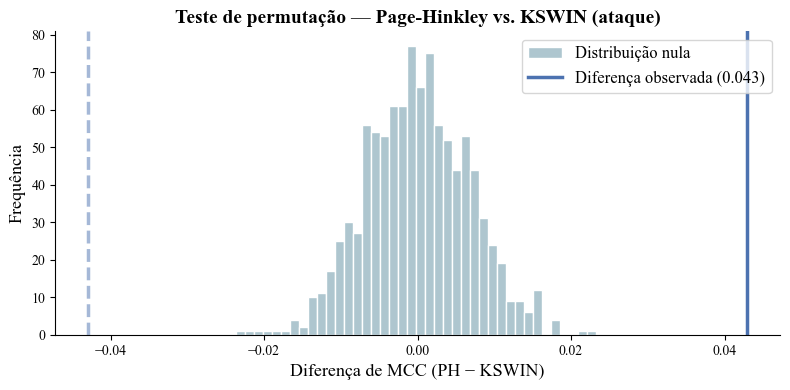

In [56]:
N_PERM = 1000
rng = np.random.default_rng(42)

GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

def _agg_raw_gc(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
    g['mcc'] = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    return g

raw_ph = pd.read_parquet('../results/model_v5_k10/02_model_page_hinkley/results_raw.parquet')
raw_ph = raw_ph[raw_ph['task'] == TASK].copy()
best_ph = _agg_raw_gc(raw_ph, GC).sort_values('mcc', ascending=False).iloc[0]

mask_ph = (
    (raw_ph['window_ma']        == best_ph.window_ma) &
    (raw_ph['cooldown_minutes'] == best_ph.cooldown_minutes) &
    (raw_ph['feature']          == best_ph.feature) &
    (raw_ph['params']           == best_ph.params)
)
ph_by_match = (raw_ph[mask_ph]
               .groupby('match_id', as_index=False)
               .agg(TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
               .sort_values('match_id').reset_index(drop=True))

raw_ks = pd.read_parquet('../results/model_v5_k10/02_model_kswin/results_raw.parquet')
raw_ks = raw_ks[raw_ks['task'] == TASK].copy()
best_ks = _agg_raw_gc(raw_ks, GC).sort_values('mcc', ascending=False).iloc[0]

mask_ks = (
    (raw_ks['window_ma']        == best_ks.window_ma) &
    (raw_ks['cooldown_minutes'] == best_ks.cooldown_minutes) &
    (raw_ks['feature']          == best_ks.feature) &
    (raw_ks['params']           == best_ks.params)
)
ks_by_match = (raw_ks[mask_ks]
               .groupby('match_id', as_index=False)
               .agg(TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
               .sort_values('match_id').reset_index(drop=True))

common = sorted(set(ph_by_match['match_id']) & set(ks_by_match['match_id']))
ph = ph_by_match[ph_by_match['match_id'].isin(common)].sort_values('match_id').reset_index(drop=True)
ks = ks_by_match[ks_by_match['match_id'].isin(common)].sort_values('match_id').reset_index(drop=True)
n  = len(common)
print(f"Partidas em comum: {n}")

def mcc_global(df):
    tp = df['TP'].sum(); fp = df['FP'].sum()
    fn = df['FN'].sum(); tn = df['TN'].sum()
    return mcc_from_counts(tp, fp, fn, tn)

mcc_ph_obs = mcc_global(ph)
mcc_ks_obs = mcc_global(ks)
diff_obs   = mcc_ph_obs - mcc_ks_obs
print(f"MCC Page-Hinkley: {mcc_ph_obs:.4f}  (W={int(best_ph.window_ma)}, C={int(best_ph.cooldown_minutes)}, {best_ph.feature})")
print(f"MCC KSWIN:        {mcc_ks_obs:.4f}  (W={int(best_ks.window_ma)}, C={int(best_ks.cooldown_minutes)}, {best_ks.feature})")
print(f"Diferença observada: {diff_obs:.4f}")

cols = ['TP', 'FP', 'FN', 'TN']
ph_vals = ph[cols].values.copy()
ks_vals = ks[cols].values.copy()

diffs_perm = np.empty(N_PERM)
for i in range(N_PERM):
    swap = rng.integers(0, 2, size=n).astype(bool)
    ph_perm = np.where(swap[:, None], ks_vals, ph_vals)
    ks_perm = np.where(swap[:, None], ph_vals, ks_vals)
    m_a = mcc_from_counts(ph_perm[:,0].sum(), ph_perm[:,1].sum(),
                           ph_perm[:,2].sum(), ph_perm[:,3].sum())
    m_b = mcc_from_counts(ks_perm[:,0].sum(), ks_perm[:,1].sum(),
                           ks_perm[:,2].sum(), ks_perm[:,3].sum())
    diffs_perm[i] = m_a - m_b

p_value = (np.abs(diffs_perm) >= np.abs(diff_obs)).mean()
print(f"\n=== Resultado ({N_PERM} permutações) ===")
print(f"p-valor (bicaudal): {p_value:.4f}")
if p_value < 0.05:
    print("→ Diferença estatisticamente significativa (p < 0,05)")
else:
    print("→ Diferença NÃO significativa (p ≥ 0,05)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diffs_perm, bins=40, color='#aec6cf', edgecolor='white', label='Distribuição nula')
ax.axvline(diff_obs, color='#4C72B0', linewidth=2.5, label=f'Diferença observada ({diff_obs:.3f})')
ax.axvline(-diff_obs, color='#4C72B0', linewidth=2.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Diferença de MCC (PH − KSWIN)', fontsize=13)
ax.set_ylabel('Frequência', fontsize=13)
ax.set_title('Teste de permutação — Page-Hinkley vs. KSWIN (ataque)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_permutacao_ph_ks.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 15. Comparação k=5 vs k=10 vs k=15 (ataque)

In [57]:
K_VALUES  = [5, 10, 15]
DETECTORS_K = [
    ('v4 Page-Hinkley', '02_model_page_hinkley'),
    ('v5 KSWIN',        '02_model_kswin'),
    ('v6 ADWIN',        '02_model_adwin'),
    ('v7 Baseline Fixo','02_model_baseline_fixed'),
]

rows_k = []
for k in K_VALUES:
    for label, folder in DETECTORS_K:
        df = pd.read_parquet(f'../results/model_v5_k{k}/{folder}/results_best.parquet')
        df = df[df['task'] == 'attack'].copy()
        if 'fast_grid' in df.columns:
            df = df[df['fast_grid'] == False]
        gc = ['window_ma'] if label != 'v7 Baseline Fixo' else ['interval_minutes']
        g = df.groupby(gc, as_index=False).agg(
            TP=('TP_sum','sum'), FP=('FP_sum','sum'),
            FN=('FN_sum','sum'), TN=('TN_sum','sum')
        )
        g['mcc']       = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
        g['f1']        = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
        g['f05']       = g.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
        g['precision'] = g['TP'] / (g['TP'] + g['FP'])
        g['recall']    = g['TP'] / (g['TP'] + g['FN'])
        g['alarms']    = g['TP'] + g['FP']
        best = g.sort_values('mcc', ascending=False).iloc[0]
        rows_k.append({
            'k': k, 'modelo': label, 'Modelo': NOMES[label],
            'MCC':       round(best.mcc, 4),
            'F1':        round(best.f1, 4),
            'F0.5':      round(best.f05, 4),
            'Precision': round(best.precision, 4),
            'Recall':    round(best.recall, 4),
            'Alarmes':   int(best.alarms),
        })

# Aleatório por k — mesma correção da seção de helpers: results_best tem 3 linhas
# por (run_number, team) pois foram testadas 3 features. Média entre features antes
# de agregar por run para não triplicar os alarmes.
v8_by_k = {}
for k in K_VALUES:
    v8k = pd.read_parquet(f'../results/model_v5_k{k}/02_model_baseline_random/results_best.parquet')
    v8k = v8k[v8k['task'] == 'attack'].copy()
    v8k_by_feat = v8k.groupby(['run_number', 'feature'], as_index=False).agg(
        TP=('TP_sum','sum'), FP=('FP_sum','sum'), FN=('FN_sum','sum'), TN=('TN_sum','sum')
    )
    runs = v8k_by_feat.groupby('run_number', as_index=False).agg(
        TP=('TP','mean'), FP=('FP','mean'), FN=('FN','mean'), TN=('TN','mean')
    )
    runs['mcc']       = runs.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    runs['f1']        = 2*runs['TP'] / (2*runs['TP'] + runs['FP'] + runs['FN'])
    runs['f05']       = runs.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
    runs['precision'] = runs['TP'] / (runs['TP'] + runs['FP'])
    runs['recall']    = runs['TP'] / (runs['TP'] + runs['FN'])
    runs['alarms']    = runs['TP'] + runs['FP']
    v8_by_k[k] = {'mean': runs.mean(numeric_only=True), 'std': runs.std(numeric_only=True)}
    rows_k.append({
        'k': k, 'modelo': 'v8 Random Walk', 'Modelo': 'Aleatório',
        'MCC':       round(runs['mcc'].mean(), 4),
        'F1':        round(runs['f1'].mean(),  4),
        'F0.5':      round(runs['f05'].mean(), 4),
        'Precision': round(runs['precision'].mean(), 4),
        'Recall':    round(runs['recall'].mean(), 4),
        'Alarmes':   int(runs['alarms'].mean()),
    })

df_k = pd.DataFrame(rows_k)
print(df_k.to_string(index=False))

 k           modelo        Modelo    MCC     F1   F0.5  Precision  Recall  Alarmes
 5  v4 Page-Hinkley  Page-Hinkley 0.0882 0.0865 0.0625     0.0528  0.2387     7870
 5         v5 KSWIN         KSWIN 0.0787 0.0878 0.0703     0.0621  0.1501     3294
 5         v6 ADWIN         ADWIN 0.0293 0.0112 0.0255     0.1714  0.0058       56
 5 v7 Baseline Fixo Baseline Fixo 0.0242 0.0392 0.0297     0.0255  0.0847     3040
10  v4 Page-Hinkley  Page-Hinkley 0.1372 0.1187 0.0846     0.0709  0.3639    13390
10         v5 KSWIN         KSWIN 0.1123 0.1191 0.0967     0.0860  0.1939     5616
10         v6 ADWIN         ADWIN 0.0348 0.0158 0.0347     0.1683  0.0083      123
10 v7 Baseline Fixo Baseline Fixo 0.0373 0.0500 0.0378     0.0325  0.1080     3040
15  v4 Page-Hinkley  Page-Hinkley 0.1544 0.1371 0.0997     0.0843  0.3664    18902
15         v5 KSWIN         KSWIN 0.0880 0.1002 0.0895     0.0836  0.1249     6503
15         v6 ADWIN         ADWIN 0.0032 0.0005 0.0011     0.0667  0.0002       15
15 v

In [58]:
# Tabelas pivot por métrica
for metric in ['MCC', 'F1', 'Recall']:
    piv = df_k.pivot(index='Modelo', columns='k', values=metric)
    piv.columns = [f'k={c}' for c in piv.columns]
    display(
        piv.style
        .format('{:.4f}')
        .highlight_max(axis=1, color='#d4edda')
        .highlight_min(axis=1, color='#f8d7da')
        .set_caption(f'{metric} — melhor config por modelo × k (ataque)')
    )

,k=5,k=10,k=15
Modelo,,,
ADWIN,0.0293,0.0348,0.0032
Aleatório,0.0586,0.0652,0.0600
Baseline Fixo,0.0242,0.0373,0.0690
KSWIN,0.0787,0.1123,0.0880
Page-Hinkley,0.0882,0.1372,0.1544


,k=5,k=10,k=15
Modelo,,,
ADWIN,0.0112,0.0158,0.0005
Aleatório,0.0373,0.0388,0.0377
Baseline Fixo,0.0392,0.0500,0.0760
KSWIN,0.0878,0.1191,0.1002
Page-Hinkley,0.0865,0.1187,0.1371


,k=5,k=10,k=15
Modelo,,,
ADWIN,0.0058,0.0083,0.0002
Aleatório,0.7592,0.7884,0.7650
Baseline Fixo,0.0847,0.1080,0.1640
KSWIN,0.1501,0.1939,0.1249
Page-Hinkley,0.2387,0.3639,0.3664


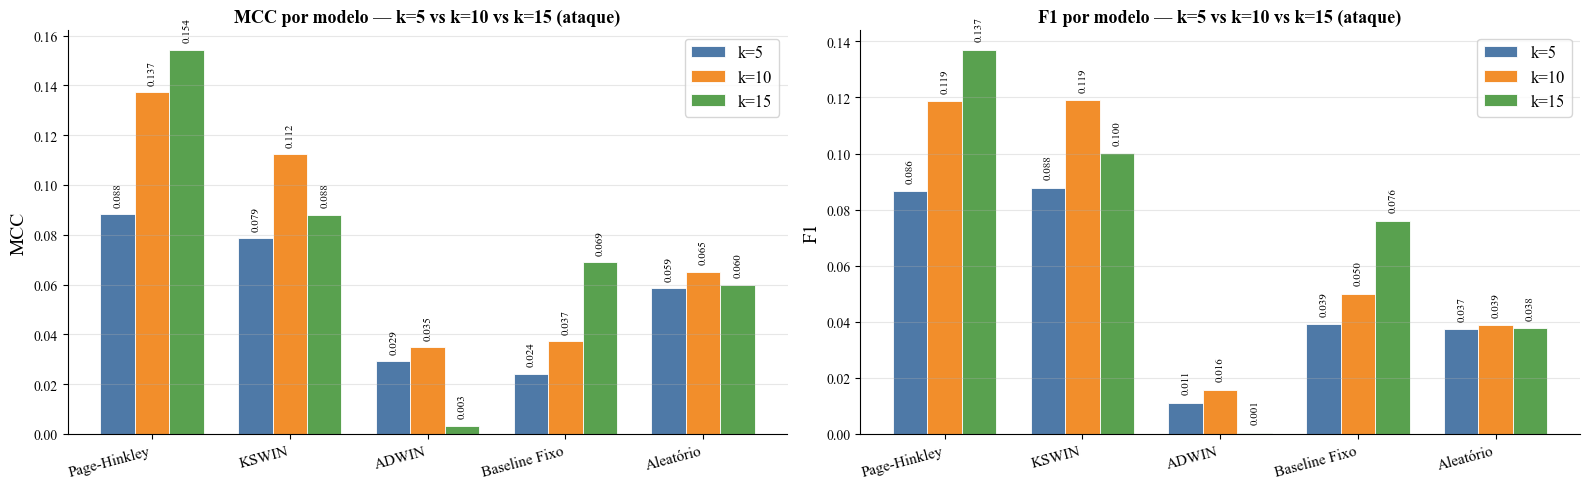

In [59]:
# Barras agrupadas: MCC e F1 por modelo × k
order_models = ['v4 Page-Hinkley','v5 KSWIN','v6 ADWIN','v7 Baseline Fixo','v8 Random Walk']
k_colors = {5: '#4e79a7', 10: '#f28e2b', 15: '#59a14f'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, ['MCC', 'F1']):
    modelos_order = [NOMES[m] for m in order_models]
    x = np.arange(len(modelos_order))
    w = 0.25
    offsets = [-w, 0, w]

    for k, offset in zip(K_VALUES, offsets):
        vals = [
            df_k[(df_k['k'] == k) & (df_k['modelo'] == m)][metric].values[0]
            for m in order_models
        ]
        bars = ax.bar(x + offset, vals, w, label=f'k={k}',
                      color=k_colors[k], edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(modelos_order, rotation=15, ha='right', fontsize=11)
    ax.set_ylabel(metric, fontsize=14)
    ax.set_title(f'{metric} por modelo — k=5 vs k=10 vs k=15 (ataque)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_k_comparacao_mcc_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

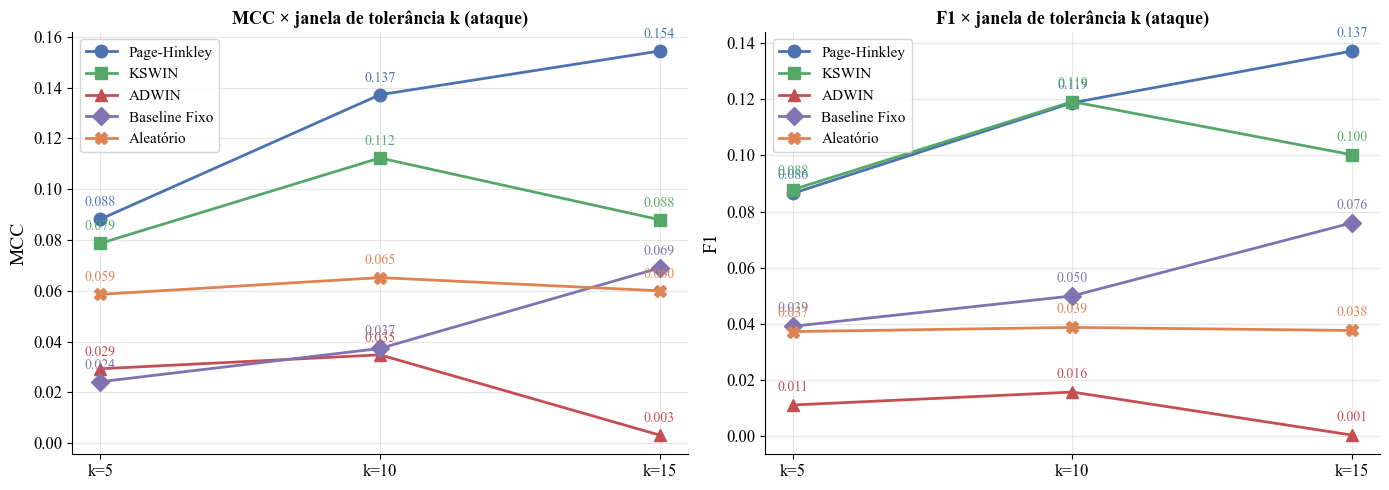

In [60]:
# Curva de k: como cada modelo evolui de k=5 → k=10 → k=15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['MCC', 'F1']):
    for label in order_models:
        sub = df_k[df_k['modelo'] == label].sort_values('k')
        ax.plot(sub['k'], sub[metric],
                marker=MARKERS[label], color=PALETTE[label],
                linewidth=2, markersize=9, label=NOMES[label])
        for _, row in sub.iterrows():
            ax.text(row['k'], row[metric] + 0.004,
                    f"{row[metric]:.3f}", ha='center', va='bottom',
                    fontsize=10, color=PALETTE[label])

    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([f'k={k}' for k in K_VALUES], fontsize=12)
    ax.set_ylabel(metric, fontsize=14)
    ax.set_title(f'{metric} × janela de tolerância k (ataque)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_k_curva_mcc_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 16. Limitações estruturais do recall

Dois casos independentes reduzem o recall independentemente da qualidade do detector:

- **Caso 1**: gol nos primeiros K minutos do período → sem janela de alarme antes (FN estrutural)
- **Caso 2**: gol a menos de K minutos após outro gol no mesmo período → janelas sobrepostas, um único alarme pode cobrir ambos os eventos

A sobreposição entre os dois casos evita dupla contagem ao calcular o total afetado.

In [ ]:
import pandas as pd

df = pd.read_parquet('../data/processed/events_wide_minute.parquet')

# gol_open_play corresponde a task='attack' + goal_type='open_play',
# que é exatamente o TASK usado neste notebook
gols = df[
    df['gol_open_play_casa'].fillna(0).astype(bool) |
    df['gol_open_play_fora'].fillna(0).astype(bool)
][['match_id', 'period', 'minute_in_period']].copy()

gols = gols.sort_values(['match_id', 'period', 'minute_in_period']).reset_index(drop=True)
gols['prev_min'] = gols.groupby(['match_id', 'period'])['minute_in_period'].shift(1)
gols['gap'] = gols['minute_in_period'] - gols['prev_min']

total = len(gols)
K = 10  # consistente com este notebook

caso1 = gols['minute_in_period'] < K
caso2 = gols['gap'].fillna(999) < K
n1    = caso1.sum()
n2    = caso2.sum()
both  = (caso1 & caso2).sum()
uniao = (caso1 | caso2).sum()

print(f'Total de gols open play (task=attack): {total}')
print(f'K={K}')
print(f'  Caso 1 (primeiros {K} min do período):  {n1} ({100*n1/total:.1f}%)')
print(f'  Caso 2 (gol anterior < {K} min):        {n2} ({100*n2/total:.1f}%)')
print(f'  Sobreposição (ambos):                   {both} ({100*both/total:.1f}%)')
print(f'  União (ao menos um caso):               {uniao} ({100*uniao/total:.1f}%)')